In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import pickle
import matplotlib.pyplot as plt
import numpy as np
from panel_utils import detect_outlier_regions_iqr

In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################

df_zakred = pd.read_excel("Clustering.xlsx", sheet_name="Zakred_cut")
df_hank   = pd.read_excel("Clustering.xlsx", sheet_name="HANK")


df_zakred["Date"]   = pd.to_datetime(df_zakred["Date"], dayfirst=True, errors="coerce")
df_hank["Date"]   = pd.to_datetime(df_hank["Date"], dayfirst=True, errors="coerce")

cols_hank = ["No_food", "No_clothes", "No_durable_goods", "No_car", "Enough_for_everything"]
for c in cols_hank:
    df_hank[c] = pd.to_numeric(df_hank[c], errors="coerce")

df_h = df_hank.merge(df_zakred[["Region", "Date", "Zakred"]],
                     on=["Region", "Date"], how="inner")
df_h["Year"] = df_h["Date"].dt.year


In [3]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [
    "No_food", "No_clothes", "No_durable_goods",
            "No_car", "Enough_for_everything"
]
region_quality_iqr = detect_outlier_regions_iqr(df_h, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_h = df_h[df_h['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_h.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 78 РЕГИОНОВ (IQR)
                      Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
              Алтайский край     71   0.0%             0    0.0%                                  KEEP
            Амурская область     71   0.0%             0    0.0%                                  KEEP
       Архангельская область     71   0.0%             2    2.8%                                  KEEP
        Астраханская область     71   0.0%             9   12.7%                                  KEEP
        Белгородская область     71   0.0%             7    9.9%                                  KEEP
            Брянская область     71   0.0%             9   12.7%                                  KEEP
        Владимирская область     71   0.0%             0    0.0%                                  KEEP
       Волгоградская область     71   0.0%             3    4.2%                                  KEEP
         Волог

In [4]:
df_h = df_h[df_h['Region'] != 'Республика Тыва']
# Выбираем за какие годы проводим кластеризацию
df_h_recent = df_h[df_h["Year"].isin([2019, 2020, 2021, 2022, 2023, 2024])]

df_h_year = (
    df_h_recent
    .groupby("Region", as_index=False)
    .agg(
        No_food=("No_food", "median"),
        No_clothes=("No_clothes", "median"),
        No_durable_goods=("No_durable_goods", "median"),
        No_car=("No_car", "median"),
        Enough_for_everything=("Enough_for_everything", "median"),
       # Zakred=("Zakred", "mean")
    )
)

with open('filter_for_cluster.pkl', 'rb') as f:
    good_regions_iqr = pickle.load(f)

df_clust = df_h_year[df_h_year["Region"].isin(good_regions_iqr)].dropna().copy()

features = ["No_food", "No_clothes", "No_durable_goods",
            "No_car", "Enough_for_everything",
            #"Zakred"
           ]
X = df_clust[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
###############################
    #ПОДБОР ЧИСЛА КЛАСТЕРОВ
###############################
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

k=2: inertia=249.51, silhouette=0.2837
k=3: inertia=185.58, silhouette=0.3148
k=4: inertia=148.78, silhouette=0.2870
k=5: inertia=123.37, silhouette=0.2924
k=6: inertia=104.01, silhouette=0.3028
k=7: inertia=90.34, silhouette=0.2965
k=8: inertia=82.78, silhouette=0.2734
k=9: inertia=72.87, silhouette=0.2764
k=10: inertia=67.51, silhouette=0.2802


Лучшее k по силуэту: 3


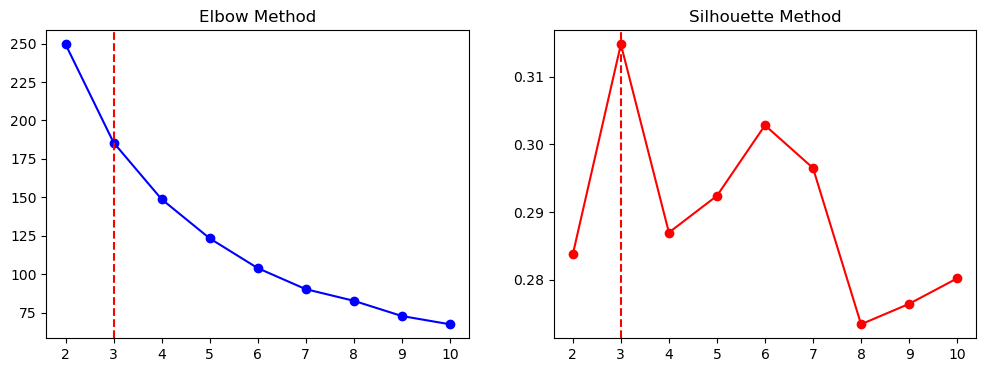

In [6]:
# Лучший k по силуэту
best_k_sil = K_range[np.argmax(silhouette_scores)]
print(f"Лучшее k по силуэту: {best_k_sil}")

# Локоть – более субъективно, но можно взять 3-4
elbow_k = 3  # или по графику

# Графики для интерпретации
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.axvline(best_k_sil, color='r', linestyle='--', label=f'best_k_sil={best_k_sil}')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.axvline(best_k_sil, color='r', linestyle='--')
ax2.set_title('Silhouette Method')

plt.show()


In [7]:
###############################
    #ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ
###############################

optimal_k = 4 # можно поменять, исходя из вывода выше
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clust["Cluster"] = kmeans.fit_predict(X_scaled) + 1

In [8]:
closest_regions = []

for cl in sorted(df_clust["Cluster"].unique()):
    mask = df_clust["Cluster"] == cl
    points = X_scaled[mask]

    # индекс центроида = номер кластера - 1
    center = kmeans.cluster_centers_[cl - 1]

    dists = np.linalg.norm(points - center, axis=1)
    idx_min = dists.argmin()

    row_closest = df_clust[mask].iloc[idx_min]
    closest_regions.append(row_closest)

closest_df = pd.DataFrame(closest_regions)
print(closest_df[["Cluster", "Region", "No_food", "No_clothes", "No_durable_goods",
            "No_car", "Enough_for_everything"]])


    Cluster               Region   No_food  No_clothes  No_durable_goods  \
74        1       г. Севастополь  0.000000    7.665056         37.905669   
20        2   Краснодарский край  0.000000   15.402842         61.725540   
1         3     Амурская область  0.402298   17.693590         43.403444   
49        4  Республика Мордовия  0.000000   10.365199         50.713617   

       No_car  Enough_for_everything  
74  43.955232               8.473354  
20  21.286285               0.459667  
1   31.748487               6.885320  
49  38.993850               0.000000  


In [9]:
cluster_summary_hank = df_clust.groupby("Cluster").agg({
    "No_food": ["mean", "median"],
    "No_clothes": ["mean", "median"], 
    "No_durable_goods": ["mean", "median"],
    "No_car": ["mean", "median"],
    "Enough_for_everything": ["mean", "median"],
    "Region": "count"  
}).round(2).reset_index()


print("Характеристики HANK-кластеров:")
print(cluster_summary_hank.to_string(index=False))



Характеристики HANK-кластеров:
Cluster No_food        No_clothes        No_durable_goods        No_car        Enough_for_everything        Region
           mean median       mean median             mean median   mean median                  mean median  count
      1    0.02   0.00       9.77   8.55            38.46  37.71  43.39  45.05                  6.94   6.68     14
      2    0.04   0.00      14.79  14.85            62.40  62.74  20.95  21.29                  0.78   0.37     25
      3    0.39   0.35      17.85  17.63            48.73  49.56  27.81  28.17                  4.92   5.05      8
      4    0.01   0.00       8.04   7.83            52.14  51.41  37.99  38.72                  1.21   0.50     24


In [10]:
# Список регионов по HANK-кластерам
hank_clusters_regions = (
    df_clust
    .sort_values(["Cluster", "Region"])
    .groupby("Cluster")["Region"]
    .apply(list)
    .reset_index(name="Regions")
)

print("=== HANK-КЛАСТЕРЫ ===")
for _, row in hank_clusters_regions.iterrows():
    cluster_id = row["Cluster"]
    regions = row["Regions"]
    n_regions = len(regions)
    
    print(f"\n Кластер {cluster_id} ({n_regions} регионов):")
    for r in sorted(regions):  # алфавитный порядок
        print(f"  {r}")
    print("-" * 50)


=== HANK-КЛАСТЕРЫ ===

 Кластер 1 (14 регионов):
  Архангельская область
  Ивановская область
  Калининградская область
  Костромская область
  Магаданская область
  Мурманская область
  Республика Татарстан
  Ростовская область
  Сахалинская область
  Тюменская область
  Чукотский автономный округ
  г. Москва
  г. Санкт-Петербург
  г. Севастополь
--------------------------------------------------

 Кластер 2 (25 регионов):
  Алтайский край
  Астраханская область
  Брянская область
  Воронежская область
  Еврейская автономная область
  Иркутская область
  Краснодарский край
  Курская область
  Новгородская область
  Новосибирская область
  Омская область
  Оренбургская область
  Орловская область
  Пензенская область
  Псковская область
  Республика Адыгея
  Республика Алтай
  Республика Хакасия
  Рязанская область
  Свердловская область
  Смоленская область
  Ставропольский край
  Тверская область
  Тульская область
  Ульяновская область
-----------------------------------------------

In [11]:
region_cluster = df_clust[['Region', 'Cluster']].copy()
region_cluster.head()

,Region,Cluster
0,Алтайский край,2
1,Амурская область,3
2,Архангельская область,1
3,Астраханская область,2
4,Белгородская область,4


In [12]:
#region_cluster.to_excel('region_cluster.xlsx')

In [13]:
cluster_dummies = pd.get_dummies(region_cluster['Cluster'],prefix='Cluster_HANK').astype(int)

region_cluster = pd.concat([region_cluster, cluster_dummies], axis=1)



region_cluster.head()

KeyError: "['Cluster_HANK'] not found in axis"

In [14]:
pickle_filename = 'region_cluster_hank_dataset.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(region_cluster, f)